# Model Serving: the KV Cache, Batching, and What Limits Throughput

The lecture claims three numbers about serving a model. This notebook checks all
three on a model small enough to run here:

1. the KV cache is **128 KiB per token** for Llama-3-8B, so one 8k conversation
   costs **1 GiB** — and the cache, not the weights, is what limits how many
   users fit at once;
2. caching keys and values makes generation **linear** in the number of tokens
   generated instead of quadratic, and changes nothing about the output;
3. **continuous batching** beats static batching whenever requests differ in
   length, which they always do.

Nothing here needs a GPU or a downloaded checkpoint.

In [1]:
import math, time
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 26525
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
torch.set_num_threads(4)

## 1. What the cache costs

Attention at position $t$ compares the query $q_t$ against the key of every
earlier position and averages those positions' values:

$$\operatorname{Attn}(q_t)=\sum_{s\le t}\alpha_{ts}\,v_s,
\qquad \alpha_{ts}\propto\exp\{q_t^\top k_s/\sqrt d\}.$$

The pairs $(k_s,v_s)$ do not depend on $t$. Computed once, they are read back at
every later step — that is the whole idea, and the storage it implies is

$$2\ (\text{for }K\text{ and }V)\times \text{layers}\times \text{KV width}\times \text{bytes}.$$

The KV width is where grouped-query attention earns its keep: Llama-3-8B is
4096 wide, but it keeps only 8 key/value heads of dimension 128, so its cache is
1024 wide, not 4096.

In [2]:
def kv_cache_bytes_per_token(layers, kv_width, bytes_per_number=2):
    return 2 * layers * kv_width * bytes_per_number

KIB, GIB = 1024, 1024 ** 3
mha = kv_cache_bytes_per_token(layers=32, kv_width=4096)   # if it used plain attention
gqa = kv_cache_bytes_per_token(layers=32, kv_width=8 * 128)  # 8 KV heads, dim 128

print(f'multi-head attention : {mha/KIB:6.0f} KiB per token')
print(f'grouped-query (actual): {gqa/KIB:6.0f} KiB per token   ({mha/gqa:.0f}x smaller)')
print()
for context in [2048, 8192, 32768]:
    print(f'  a {context:>6,}-token conversation holds {gqa*context/GIB:6.2f} GiB of cache')

multi-head attention :    512 KiB per token
grouped-query (actual):    128 KiB per token   (4x smaller)

  a  2,048-token conversation holds   0.25 GiB of cache
  a  8,192-token conversation holds   1.00 GiB of cache
  a 32,768-token conversation holds   4.00 GiB of cache


In [3]:
# The consequence: on one 80 GiB accelerator, how many users fit at once?
weights = 8.03e9 * 2 / GIB          # 8.03 B parameters at two bytes each
budget = 80 - weights - 2           # leave 2 GiB for activations and workspace

rows = []
for context in [1024, 4096, 8192, 32768]:
    per_user = gqa * context / GIB
    rows.append((context, per_user, int(budget // per_user)))

print(f'weights occupy {weights:.1f} GiB, leaving {budget:.1f} GiB for cache\n')
print(f"{'context':>9} {'GiB/user':>10} {'concurrent users':>18}")
for context, per_user, users in rows:
    print(f'{context:>9,} {per_user:>10.2f} {users:>18,}')
print()
print('The weights are a fixed cost paid once. The cache is paid per user, per')
print('token, and it is what actually runs out.')

weights occupy 15.0 GiB, leaving 63.0 GiB for cache

  context   GiB/user   concurrent users
    1,024       0.12                504
    4,096       0.50                126
    8,192       1.00                 63
   32,768       4.00                 15

The weights are a fixed cost paid once. The cache is paid per user, per
token, and it is what actually runs out.


## 2. The cache, implemented

Below is a small decoder with an optional cache. The only difference from the
uncached version is three lines: append this step's keys and values to what is
stored, and attend over the whole stored history.

The test that matters is not the timing but the first line of output: caching is
an optimization, so it must not change a single generated token.

In [4]:
VOCAB, WIDTH, LAYERS, HEADS = 256, 128, 4, 4

class CachedAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.head_dim = WIDTH // HEADS
        self.qkv = nn.Linear(WIDTH, 3 * WIDTH)
        self.out = nn.Linear(WIDTH, WIDTH)

    def forward(self, x, cache=None):
        batch, steps, _ = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        split = lambda z: z.view(batch, steps, HEADS, self.head_dim).transpose(1, 2)
        q, k, v = map(split, (q, k, v))
        if cache is not None:
            if cache['k'] is not None:                       # read the history back
                k = torch.cat([cache['k'], k], dim=2)
                v = torch.cat([cache['v'], v], dim=2)
            cache['k'], cache['v'] = k, v                    # and store the extension
        # A single new query attends to everything stored, so no mask is needed;
        # a full prefill pass still needs the causal mask.
        causal = k.shape[2] == q.shape[2]
        attended = F.scaled_dot_product_attention(q, k, v, is_causal=causal)
        return self.out(attended.transpose(1, 2).reshape(batch, steps, WIDTH))

class ServingBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1, self.attention = nn.LayerNorm(WIDTH), CachedAttention()
        self.norm2 = nn.LayerNorm(WIDTH)
        self.mlp = nn.Sequential(nn.Linear(WIDTH, 4 * WIDTH), nn.GELU(),
                                 nn.Linear(4 * WIDTH, WIDTH))
    def forward(self, x, cache=None):
        x = x + self.attention(self.norm1(x), cache)
        return x + self.mlp(self.norm2(x))

class ServingModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token = nn.Embedding(VOCAB, WIDTH)
        self.position = nn.Embedding(4096, WIDTH)
        self.blocks = nn.ModuleList([ServingBlock() for _ in range(LAYERS)])
        self.norm, self.head = nn.LayerNorm(WIDTH), nn.Linear(WIDTH, VOCAB)
    def forward(self, index, caches=None, offset=0):
        steps = index.shape[1]
        x = self.token(index) + self.position(torch.arange(offset, offset + steps))
        for i, block in enumerate(self.blocks):
            x = block(x, None if caches is None else caches[i])
        return self.head(self.norm(x))

served = ServingModel().eval()
print(f'{sum(p.numel() for p in served.parameters()):,} parameters')

1,383,424 parameters


In [5]:
@torch.no_grad()
def generate_without_cache(index, new_tokens):
    # Every step re-reads the entire prefix and recomputes every key and value.
    for _ in range(new_tokens):
        nxt = served(index)[:, -1].argmax(-1, keepdim=True)
        index = torch.cat([index, nxt], dim=1)
    return index

@torch.no_grad()
def generate_with_cache(index, new_tokens):
    caches = [{'k': None, 'v': None} for _ in range(LAYERS)]
    logits = served(index, caches, offset=0)          # prefill: one dense pass
    nxt = logits[:, -1].argmax(-1, keepdim=True)
    output = torch.cat([index, nxt], dim=1)
    for step in range(new_tokens - 1):                # decode: one token at a time
        logits = served(nxt, caches, offset=index.shape[1] + step)
        nxt = logits[:, -1].argmax(-1, keepdim=True)
        output = torch.cat([output, nxt], dim=1)
    return output

prompt = torch.randint(0, VOCAB, (1, 32))
timings = []
for new_tokens in [32, 64, 128, 256]:
    start = time.perf_counter(); plain = generate_without_cache(prompt, new_tokens)
    plain_time = time.perf_counter() - start
    start = time.perf_counter(); cached = generate_with_cache(prompt, new_tokens)
    cached_time = time.perf_counter() - start
    assert torch.equal(plain, cached), 'the cache changed the output'
    timings.append((new_tokens, plain_time, cached_time))
    print(f'{new_tokens:>4} new tokens   identical output   '
          f'no cache {plain_time:5.2f}s   cache {cached_time:5.2f}s   '
          f'{plain_time/cached_time:4.1f}x')

  32 new tokens   identical output   no cache  0.04s   cache  0.02s    2.4x


  64 new tokens   identical output   no cache  0.09s   cache  0.03s    2.5x


 128 new tokens   identical output   no cache  0.20s   cache  0.07s    2.9x


 256 new tokens   identical output   no cache  0.61s   cache  0.16s    3.8x


Without a cache, generating T tokens attends over 1+2+...+T positions, so the
work grows with T^2. With a cache each step attends over the history once and
the work grows with T. The gap widens with every token, which is why no serving
system generates without one.


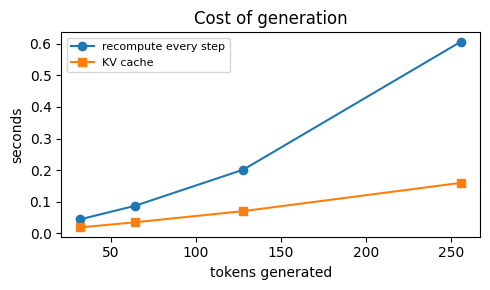

In [6]:
lengths = np.array([t[0] for t in timings])
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(lengths, [t[1] for t in timings], 'o-', label='recompute every step')
ax.plot(lengths, [t[2] for t in timings], 's-', label='KV cache')
ax.set_xlabel('tokens generated'); ax.set_ylabel('seconds')
ax.set_title('Cost of generation'); ax.legend(fontsize=8); fig.tight_layout()

print('Without a cache, generating T tokens attends over 1+2+...+T positions, so the')
print('work grows with T^2. With a cache each step attends over the history once and')
print('the work grows with T. The gap widens with every token, which is why no serving')
print('system generates without one.')

## 3. Static against continuous batching

Throughput comes from sharing a forward pass, so the server decodes many
requests together. The question is what happens when they finish at different
times.

**Static batching** fixes the membership when the batch starts: a slot that
finishes early sits idle until the *longest* request in the batch is done.
**Continuous batching** lets a finished request leave and admits a waiting one
at the next step.

The simulation below decodes at one step per unit of time and counts, at each
step, how many slots held a live request. That fraction is the utilization the
hardware actually sees.

In [7]:
def simulate(output_lengths, slots, continuous):
    pending = list(output_lengths)
    remaining = []           # tokens still owed by each occupied slot
    finish_time = []
    step = busy = 0
    while pending or remaining:
        # Admit work. Static batching refills only when the batch is empty.
        if continuous or not remaining:
            while pending and len(remaining) < slots:
                remaining.append(pending.pop(0))
        busy += len(remaining); step += 1
        remaining = [r - 1 for r in remaining]
        for r in remaining:
            if r == 0: finish_time.append(step)
        remaining = [r for r in remaining if r > 0]
    return dict(steps=step, utilization=busy / (step * slots),
                mean_latency=float(np.mean(finish_time)))

# Output lengths in a real workload are heavy-tailed: many short replies and a
# few long ones.
workload = np.clip(rng.lognormal(mean=3.2, sigma=0.9, size=96), 5, 600).astype(int)
print(f'{len(workload)} requests, {workload.min()} to {workload.max()} tokens '
      f'(median {int(np.median(workload))})\n')

static = simulate(workload, slots=16, continuous=False)
flowing = simulate(workload, slots=16, continuous=True)
print(f"{'':>12}{'steps':>8}{'utilization':>14}{'mean latency':>15}")
for name, result in [('static', static), ('continuous', flowing)]:
    print(f"{name:>12}{result['steps']:>8,}{result['utilization']:>13.0%}"
          f"{result['mean_latency']:>15,.0f}")
print()
print(f"Continuous batching finished the same work in "
      f"{static['steps']/flowing['steps']:.2f}x fewer steps.")

96 requests, 5 to 267 tokens (median 22)

               steps   utilization   mean latency
      static     886          25%            476
  continuous     283          77%            116

Continuous batching finished the same work in 3.13x fewer steps.


Static batching gets worse as the batch grows: a bigger batch is more likely
to contain one very long request, and every other slot waits for it. This is
the tail the lecture warns about, and it is why serving systems schedule at
the granularity of a step rather than a request.


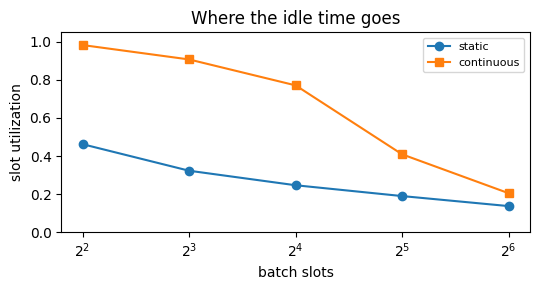

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 3))
slot_counts = [4, 8, 16, 32, 64]
for continuous, label, marker in [(False, 'static', 'o'), (True, 'continuous', 's')]:
    ax.plot(slot_counts,
            [simulate(workload, s, continuous)['utilization'] for s in slot_counts],
            marker + '-', label=label)
ax.set_xscale('log', base=2); ax.set_ylim(0, 1.05)
ax.set_xlabel('batch slots'); ax.set_ylabel('slot utilization')
ax.set_title('Where the idle time goes'); ax.legend(fontsize=8); fig.tight_layout()

print('Static batching gets worse as the batch grows: a bigger batch is more likely')
print('to contain one very long request, and every other slot waits for it. This is')
print('the tail the lecture warns about, and it is why serving systems schedule at')
print('the granularity of a step rather than a request.')